# FPC1500 Network Analyzer — S21 Kette Verstärker + Abschwächer

Kurz zur Theorie: Bei einer Kaskade (Verstärker und Abschwächer in Serie) multiplizieren sich
die Streuparameter linear: $S_{21,\mathrm{ges}} \approx S_{21,\mathrm{amp}} \, S_{21,\mathrm{att}}$.
In der logarithmischen Darstellung (dB) wird daraus eine **Summe**:

$$20\log_{10}|S_{21,\mathrm{ges}}| \approx 20\log_{10}|S_{21,\mathrm{amp}}| + 20\log_{10}|S_{21,\mathrm{att}}|.$$

Dieses Notebook lädt zuerst die zuvor gemessene Abschwächer-Kurve (`attenuator.json`),
misst dann die Transmission der **Kette** (Verstärker mit vorgeschaltetem Abschwächer im gleichen Full-Span)
und rechnet daraus die **alleinige Verstärker-Transmission** durch Entfernen des Abschwächer-Anteils (Subtraktion in dB).


## Ablauf

1. **Voraussetzung:** In Notebook `4-fpc1500-NA-S21.ipynb` wurde der Abschwächer im Full-Span gemessen; dabei wurde `recordings/attenuator.json` erzeugt.
2. **Kalibration:** Wie in den vorherigen Notebooks (gleicher Span); dann **Kette** aus Verstärker + Abschwächer messen (typische Reihenfolge: Generator → Abschwächer → Verstärker → Empfang).
3. Zuerst die Zelle **„Abschwächer einlesen“** ausführen, danach die **S21-Messung der Kette** wie gewohnt (`TRACE1`).

**Replay:** Zum erneuten Plotten ohne Gerät `REPLAY = True` setzen (Konfigurationszelle).


## RF-Amplifier Modul mit 5V DC Supply

![RF-Amplifier mit 5V Supply](media/rf-amplifier.png)

## Imports und Globale Variable

In [8]:
import json
import socket
from datetime import datetime
from pathlib import Path

# Interaktive Matplotlib-Widgets (Slider) in Jupyter: ipympl installieren, dann:
#   pip install ipympl
# Ohne ipympl nutzt oft das statische "inline"-Backend — der Slider erscheint, ist aber nicht ziehbar.
try:
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "widget")
except Exception:
    pass

import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import numpy as np
from IPython.display import Image, display

FPC_IP = "192.168.1.10"
FPC_PORT = 5555
SOCKET_TIMEOUT = 5.0
SCREENSHOT_TIMEOUT = 15.0   # HCOP und Auslesen können deutlich länger als 5 s dauern
TRACE_READ_MAX_BYTES = 2 * 1024 * 1024

# Offline-Workflow: bei REPLAY=True werden Messdaten aus JSON geladen
REPLAY = True
REPLAY_FILE = Path("recordings") / "5-fpc1500_na_s21_replay.json"
ATTENUATOR_JSON = Path("recordings") / "attenuator.json"

SCREENSHOT_DIR = Path("screenshots")
SCREENSHOT_FILENAME = "screen.png"

print(f"Konfiguration: {FPC_IP}:{FPC_PORT}")
print(f"REPLAY={REPLAY}, Datei={REPLAY_FILE}")


Konfiguration: 192.168.1.10:5555
REPLAY=True, Datei=recordings\5-fpc1500_na_s21_replay.json


In [9]:
def scpi_query(host: str, port: int, cmd: str, timeout: float = SOCKET_TIMEOUT, max_bytes: int = 4096) -> str:
    cmd = cmd.strip() + "\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(timeout)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        buf = b""
        while len(buf) < max_bytes:
            chunk = s.recv(8192)
            if not chunk:
                break
            buf += chunk
            if b"\n" in buf:
                break
        return buf.decode("utf-8", errors="replace").strip()
    finally:
        s.close()

def parse_float_list(raw: str) -> np.ndarray:
    vals = []
    for part in raw.replace(",", " ").split():
        try:
            vals.append(float(part))
        except ValueError:
            continue
    return np.asarray(vals, dtype=np.float64)

def get_freq_axis(host: str, port: int, n: int) -> np.ndarray:
    try:
        f_start = float(scpi_query(host, port, "FREQ:STAR?", max_bytes=256))
        f_stop = float(scpi_query(host, port, "FREQ:STOP?", max_bytes=256))
    except Exception:
        cent = float(scpi_query(host, port, "FREQ:CENT?", max_bytes=256))
        span = float(scpi_query(host, port, "FREQ:SPAN?", max_bytes=256))
        f_start = cent - span / 2.0
        f_stop = cent + span / 2.0
    return np.linspace(f_start, f_stop, n)

def to_s21_db(vals: np.ndarray) -> tuple[np.ndarray, str]:
    if vals.size == 0:
        return vals, "empty"
    vmin = float(np.nanmin(vals))
    vmax = float(np.nanmax(vals))
    looks_like_db = vmax <= 40.0 and vmin < 20.0
    if looks_like_db:
        return vals, "already_dB"
    s21_db = 20.0 * np.log10(np.maximum(np.abs(vals), 1e-12))
    return s21_db, "linear_to_dB"


def save_replay_json(path: Path, data: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2), encoding="utf-8")


def load_replay_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"Replay-Datei nicht gefunden: {path}")
    return json.loads(path.read_text(encoding="utf-8"))


def screenshot_save(host: str, port: int, filename: str = "screen.png") -> str | None:
    """Hardcopy auf dem Gerät auslösen und in MMEM speichern. Returns None bei Erfolg, sonst Fehlermeldung."""
    commands = ["HCOP:DEV:LANG PNG", "HCOP:DEST 'MMEM'", f"MMEM:NAME '{filename}'", "HCOP:IMM"]
    cmd = "\n".join(commands) + "\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(SCREENSHOT_TIMEOUT)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        buf = b""
        while len(buf) < 4096:
            try:
                chunk = s.recv(1024)
                if not chunk:
                    break
                buf += chunk
                if b"\n" in buf:
                    break
            except socket.timeout:
                break
        reply = buf.decode("utf-8", errors="replace").strip()
        if reply and "error" in reply.lower():
            return reply
        return None
    except Exception as e:
        return str(e)
    finally:
        s.close()


def screenshot_read(host: str, port: int, filename: str) -> bytes | None:
    """Datei vom Gerät (MMEM) lesen. MMEM:DATA? Antwort im IEEE 488.2-Blockformat. Returns PNG-Bytes oder None."""
    cmd = f"MMEM:DATA? '{filename}'\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(SCREENSHOT_TIMEOUT)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        buf = b""
        while b"#" not in buf and len(buf) < 1024:
            chunk = s.recv(256)
            if not chunk:
                return None
            buf += chunk
        if b"#" not in buf:
            return None
        start = buf.index(b"#")
        buf = buf[start:]
        if len(buf) < 2:
            buf += s.recv(2 - len(buf))
        n_digits = int(chr(buf[1]))
        if n_digits < 1 or n_digits > 9:
            return None
        while len(buf) < 2 + n_digits:
            buf += s.recv(2 + n_digits - len(buf))
        data_len = int(buf[2 : 2 + n_digits].decode())
        buf = buf[2 + n_digits :]
        while len(buf) < data_len:
            chunk = s.recv(min(65536, data_len - len(buf)))
            if not chunk:
                break
            buf += chunk
        return buf[:data_len] if len(buf) >= data_len else None
    except Exception:
        return None
    finally:
        s.close()

def align_attenuator_s21_db(freq_hz_meas: np.ndarray, atten_data: dict) -> np.ndarray:
    # Interpoliert S21 des Abschwächers (dB) auf die Messfrequenzen der Kette.
    fa = np.asarray(atten_data["freq_hz"], dtype=float)
    sa = np.asarray(atten_data["s21_db"], dtype=float)
    order = np.argsort(fa)
    fa, sa = fa[order], sa[order]
    # np.interp verlangt streng steigendes xp — doppelte fa mitteln
    if len(fa) > 1:
        uf = np.unique(fa)
        if len(uf) < len(fa):
            sa = np.array([np.mean(sa[fa == u]) for u in uf], dtype=float)
            fa = uf.astype(float)
    # Rand: NaN macht die Kurven unsichtbar, wenn f minimal außerhalb von min/max(fa) liegt
    return np.interp(
        freq_hz_meas,
        fa,
        sa,
        left=float(sa[0]),
        right=float(sa[-1]),
    )


## Abschwächer: `attenuator.json` einlesen und plotten

Die Datei stammt aus Notebook 4 (Messung nur Abschwächer, gleicher Frequenzbereich / Full-Span).


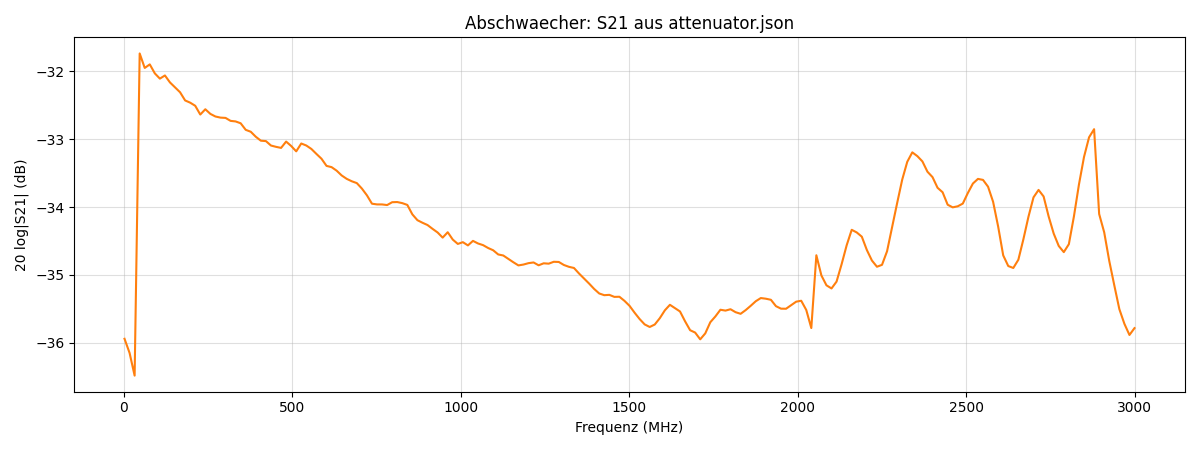

In [10]:
if not ATTENUATOR_JSON.exists():
    raise FileNotFoundError(
        f"Nicht gefunden: {ATTENUATOR_JSON.resolve()} — bitte zuerst Notebook 4 ausfuehren."
    )
attenuator_data = json.loads(ATTENUATOR_JSON.read_text(encoding="utf-8"))
f_att_hz = np.asarray(attenuator_data["freq_hz"], dtype=float)
s21_att_db = np.asarray(attenuator_data["s21_db"], dtype=float)

fig_att, ax_att = plt.subplots(figsize=(12, 4.5))
ax_att.plot(f_att_hz / 1e6, s21_att_db, color="C1", lw=1.5)
ax_att.set_title("Abschwaecher: S21 aus attenuator.json")
ax_att.set_xlabel("Frequenz (MHz)")
ax_att.set_ylabel("20 log|S21| (dB)")
ax_att.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


## Messung S21: Kette Verstärker + Abschwächer (`TRACE1`)

Wie in Notebook 4: Transmission S21 am Gerät einstellen, dann diese Zelle ausführen.
Es wird `recordings/5-fpc1500_na_s21_replay.json` geschrieben (Replay-Modus).


Replay geladen: recordings\5-fpc1500_na_s21_replay.json
Gerät: Rohde&Schwarz,FPC1500,1328.6660K03/206021,V1.90


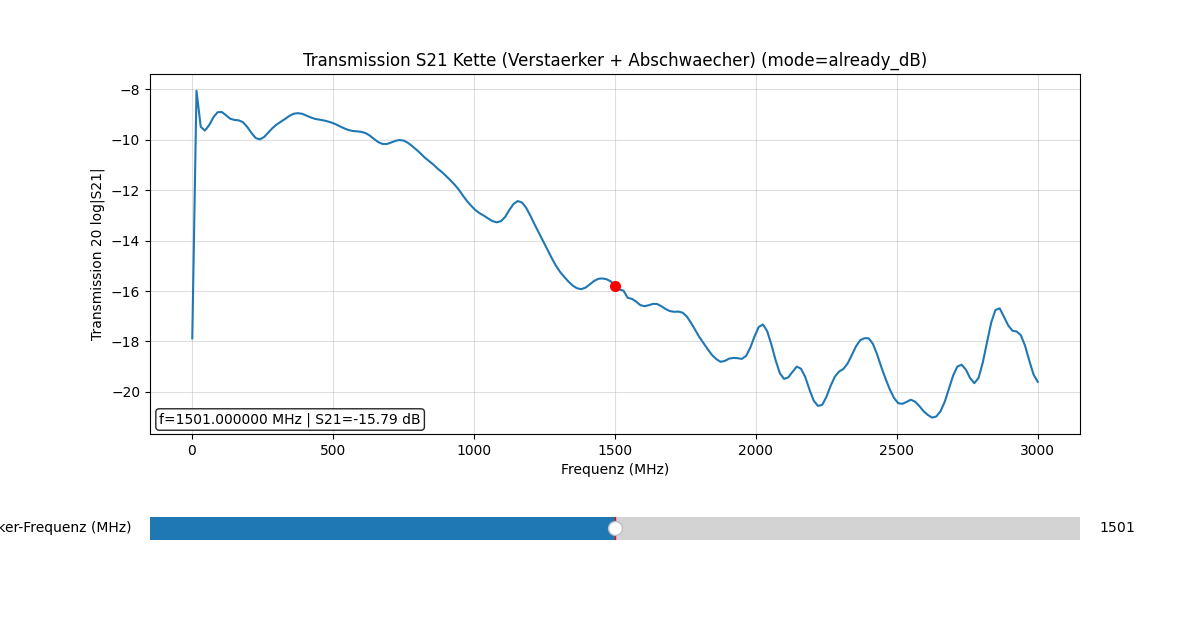

In [11]:
if REPLAY:
    replay = load_replay_json(REPLAY_FILE)
    freq_hz = np.asarray(replay["freq_hz"], dtype=float)
    trace_vals = np.asarray(replay["trace_vals"], dtype=float)
    s21_db = np.asarray(replay["s21_db"], dtype=float)
    s21_mode = replay.get("s21_mode", "replay")
    idn = replay.get("idn", "REPLAY")
    print("Replay geladen:", REPLAY_FILE)
    print("Gerät:", idn)
else:
    idn = scpi_query(FPC_IP, FPC_PORT, "*IDN?")
    print("Gerät:", idn if idn else "Keine Antwort")

    trace_raw = scpi_query(FPC_IP, FPC_PORT, "TRAC:DATA? TRACE1", max_bytes=TRACE_READ_MAX_BYTES)
    trace_vals = parse_float_list(trace_raw)
    if trace_vals.size < 2:
        raise RuntimeError("TRACE1 leer. Bitte S21-Transmission am Gerät einstellen.")

    freq_hz = get_freq_axis(FPC_IP, FPC_PORT, trace_vals.size)
    s21_db, s21_mode = to_s21_db(trace_vals)

    save_replay_json(
        REPLAY_FILE,
        {
            "meta": {"type": "fpc1500_na_s21", "version": 1},
            "idn": idn,
            "s21_mode": s21_mode,
            "freq_hz": freq_hz.tolist(),
            "trace_vals": trace_vals.tolist(),
            "s21_db": s21_db.tolist(),
        },
    )
    print("Replay gespeichert:", REPLAY_FILE)

f_mhz = freq_hz / 1e6

fig = plt.figure(figsize=(12, 6.2))
gs = fig.add_gridspec(2, 1, height_ratios=[1.0, 0.13], hspace=0.35)
ax = fig.add_subplot(gs[0, 0])
ax_slider = fig.add_subplot(gs[1, 0])

ax.plot(f_mhz, s21_db, color="C0", lw=1.5)
ax.set_title(f"Transmission S21 Kette (Verstaerker + Abschwaecher) (mode={s21_mode})")
ax.set_xlabel("Frequenz (MHz)")
ax.set_ylabel("Transmission 20 log|S21|")
ax.grid(True, alpha=0.4)

idx0 = int(np.argmin(np.abs(f_mhz - np.mean(f_mhz))))
m_s21, = ax.plot([f_mhz[idx0]], [s21_db[idx0]], "o", color="red", ms=7)
# Text im Haupt-Plot (transAxes), nicht fig.text am unteren Figurenrand — sonst überlappt
# der unsichtbare Kasten die Slider-Achse und blockiert Maus-Events.
info_text = ax.text(
    0.01,
    0.02,
    "",
    transform=ax.transAxes,
    fontsize=10,
    ha="left",
    va="bottom",
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.85),
)

slider = Slider(
    ax=ax_slider,
    label="Marker-Frequenz (MHz)",
    valmin=float(f_mhz.min()),
    valmax=float(f_mhz.max()),
    valinit=float(f_mhz[idx0]),
)

def update_marker(f_sel_mhz):
    idx = int(np.argmin(np.abs(f_mhz - f_sel_mhz)))
    m_s21.set_data([f_mhz[idx]], [s21_db[idx]])
    info_text.set_text(f"f={f_mhz[idx]:.6f} MHz | S21={s21_db[idx]:.2f} dB")
    fig.canvas.draw_idle()

slider.on_changed(update_marker)
update_marker(f_mhz[idx0])
plt.show()


## Korrektur: Verstärker allein (Full-Span)

Gemessen wurde $S_{21,\mathrm{ges}}$ der **Kette**. Der zuvor gemessene Abschwächer liefert $S_{21,\mathrm{att}}$ (dieselbe Referenz / Kalibration).

In dB gilt näherungsweise:

$$S_{21,\mathrm{amp}}^{\mathrm{(dB)}} \approx S_{21,\mathrm{ges}}^{\mathrm{(dB)}} - S_{21,\mathrm{att}}^{\mathrm{(dB)}}.$$

(Subtraktion in dB entspricht dem **Dividieren** der Beträge in Linearwerten; hier nutzen wir den in `TRACE1` ausgegebenen dB-Verlauf.)

Die Abschwächer-Kurve wird auf die Frequenzstützstellen der Kettenmessung **interpoliert**, dann punktweise subtrahiert — das ist die Umkehrung der dB-**Addition** der beiden Glieder in der Kette. Anschließend wird der korrigierte Verlauf geplottet.

**Technik:** Liegt eine Ketten-Frequenz minimal außerhalb des in `attenuator.json` gespeicherten Bereichs, würde eine naive Interpolation mit ``NaN`` am Rand **alle Kurven unbrauchbar** machen (leerer Plot). Daher werden Randwerte **konstant extrapoliert** (letzte bekannte Abschwächer-dB).

**Darstellung (ipympl):** Die Messzelle mit **Slider** erzeugt eine interaktive Figure. Unter `%matplotlib widget` kann eine **zweite** Figure danach leer erscheinen. Die Korrektur-Zelle schließt daher die Slider-Figure (`plt.close(fig)`); die Ketten-Kurve kann bei Bedarf durch erneutes Ausführen der Messzelle wieder angezeigt werden.


Korrektur: n= 201 | Kette dB min/max -21.01943016 -8.054166794 | Att(interpol.) min/max -36.48086548 -31.73938942 | Amp(korr.) min/max 13.181747440000002 28.093248366


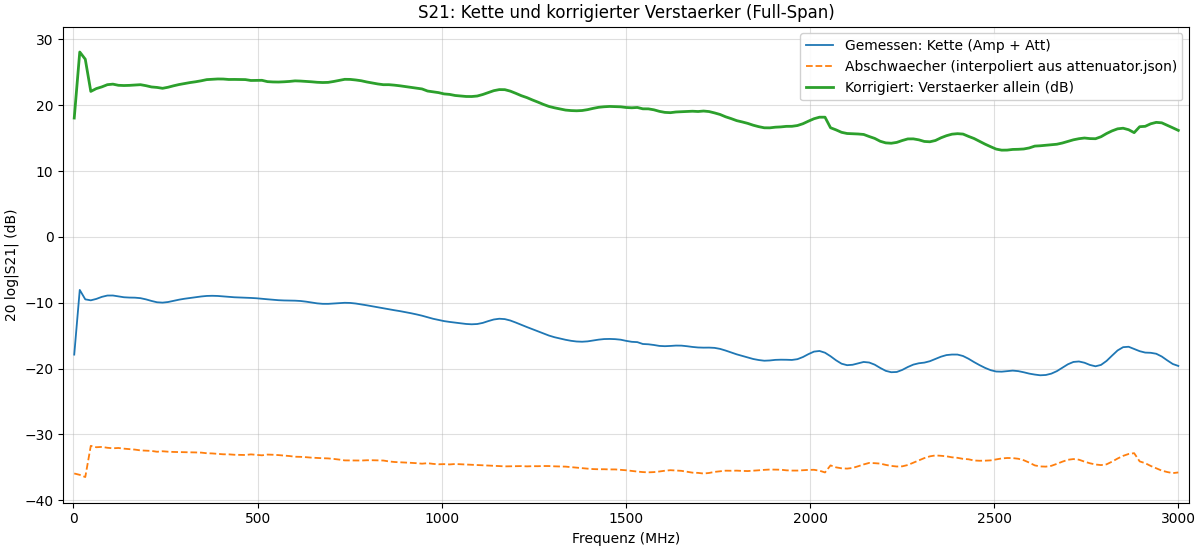

In [12]:
if not ATTENUATOR_JSON.exists():
    raise FileNotFoundError(ATTENUATOR_JSON)

attenuator_data = json.loads(ATTENUATOR_JSON.read_text(encoding="utf-8"))
s21_att_on_chain = align_attenuator_s21_db(freq_hz, attenuator_data)

s21_amp_db = np.asarray(s21_db, dtype=float) - np.asarray(s21_att_on_chain, dtype=float)

if not np.all(np.isfinite(s21_att_on_chain)):
    print(
        "Warnung: nicht-endliche Werte in interpoliertem Abschwaecher — bitte align_attenuator_s21_db pruefen."
    )

# Diagnose (sollte endliche Werte zeigen, wenn TRACE1 und attenuator.json passen)
print(
    "Korrektur: n=",
    len(freq_hz),
    "| Kette dB min/max",
    float(np.nanmin(s21_db)),
    float(np.nanmax(s21_db)),
    "| Att(interpol.) min/max",
    float(np.nanmin(s21_att_on_chain)),
    float(np.nanmax(s21_att_on_chain)),
    "| Amp(korr.) min/max",
    float(np.nanmin(s21_amp_db)),
    float(np.nanmax(s21_amp_db)),
)

# ipympl: interaktive Slider-Figure aus der Messzelle kann Folge-Plots leer lassen — schließen.
try:
    plt.close(fig)
except NameError:
    pass

fig_c, ax_c = plt.subplots(figsize=(12, 5.5), constrained_layout=True)
ax_c.plot(freq_hz / 1e6, s21_db, color="C0", lw=1.3, label="Gemessen: Kette (Amp + Att)")
ax_c.plot(
    freq_hz / 1e6,
    s21_att_on_chain,
    color="C1",
    lw=1.3,
    linestyle="--",
    label="Abschwaecher (interpoliert aus attenuator.json)",
)
ax_c.plot(
    freq_hz / 1e6,
    s21_amp_db,
    color="C2",
    lw=2.0,
    label="Korrigiert: Verstaerker allein (dB)",
)
ax_c.set_title("S21: Kette und korrigierter Verstaerker (Full-Span)")
ax_c.set_xlabel("Frequenz (MHz)")
ax_c.set_ylabel("20 log|S21| (dB)")
ax_c.grid(True, alpha=0.4)
ax_c.legend(loc="upper right", framealpha=0.9)
ax_c.margins(x=0.01, y=0.06)
fig_c.canvas.draw_idle()
plt.show()


In [13]:
# Screenshot-Handling:
# - REPLAY=False: Screenshot am Gerät auslösen, lokal speichern und Replay-Datei damit verknüpfen
# - REPLAY=True : bereits aufgezeichneten Screenshot aus Replay-Datei anzeigen (kein neuer Trigger)
# (Am Gerät sollte bei Live-Messung die S21-Transmission sichtbar sein.)

SCREENSHOT_DIR.mkdir(parents=True, exist_ok=True)

if REPLAY:
    replay = load_replay_json(REPLAY_FILE)
    shot_path_str = replay.get('screenshot_path', '')
    shot_path = Path(shot_path_str) if shot_path_str else None

    if shot_path and shot_path.exists():
        print('Replay-Screenshot geladen:', shot_path)
        display(Image(filename=str(shot_path)))
    else:
        print('REPLAY=True: Kein gültiger screenshot_path in Replay-Datei vorhanden.')
        if shot_path_str:
            print('Gespeicherter Pfad (nicht gefunden):', shot_path_str)
else:
    err = screenshot_save(FPC_IP, FPC_PORT, SCREENSHOT_FILENAME)
    if err:
        print('Screenshot speichern auf dem Gerät fehlgeschlagen:', err)
    else:
        png_bytes = screenshot_read(FPC_IP, FPC_PORT, SCREENSHOT_FILENAME)
        if png_bytes:
            out_path = SCREENSHOT_DIR / f"{REPLAY_FILE.stem.replace('_replay', '')}_screenshot.png"
            out_path.write_bytes(png_bytes)
            print('Gespeichert:', out_path.resolve())
            display(Image(data=png_bytes))

            try:
                replay = load_replay_json(REPLAY_FILE) if REPLAY_FILE.exists() else {}
                replay['screenshot_path'] = str(out_path)
                save_replay_json(REPLAY_FILE, replay)
                print('Replay aktualisiert mit screenshot_path:', REPLAY_FILE)
            except Exception as ex:
                print('Hinweis: screenshot_path konnte nicht im Replay gespeichert werden:', ex)
        else:
            print('Screenshot konnte nicht gelesen werden.')

REPLAY=True: Kein gültiger screenshot_path in Replay-Datei vorhanden.


## Erstelle **HIER** die Mess-Analyse mit Python-Code

In [12]:
# ANALYSIS- PYTHON-Code HERE
